# Analyzing Data

The purpose of this notebook is to demonstrate the beginning of analyzing data.

The data is retrieved from the national weather service and concerns the monthly average temperatures in Chicago over the past 100 years.

While reading the data from file will fail if the file is not present on the computer where this notebook is executed, the data is also available in string format and loaded into the array ``B``, so the notebook is self contained.

In [1]:
using Plots

In [2]:
using DelimitedFiles

In [3]:
using Statistics

## 1. reading a delimited file

In [4]:
A = readdlm("tempChicago100years.txt")

101×14 Matrix{Any}:
     "Year"    "Jan"    "Feb"    "Mar"  …    "Nov"    "Dec"    "Annual"
 1922        24.8     29.4     39.3        44.6     29.9     52.1
 1923        30.7     22.3     33.0        43.8     39.7     50.3
 1924        19.7     28.8     34.6        41.5     23.3     48.1
 1925        25.9     32.2     39.7        38.9     25.3     50.3
 1926        27.3     30.9     30.2     …  37.1     26.5     48.0
 1927        24.8     34.9     42.0        43.2     26.9     50.6
 1928        25.2     30.3     36.9        42.2     32.1     49.6
 1929        17.6     21.6     43.3        36.3     28.6     48.5
 1930        20.1     37.1     36.1        42.4     29.7     51.0
 1931        32.0     35.6     34.9     …  50.0     38.4     53.9
 1932        33.6     34.9     30.1        37.2     28.7     50.5
 1933        36.7     26.2     35.5        38.0     31.3     51.7
    ⋮                                   ⋱                    
 2010        21.9     26.7     41.7        41.5     22

For the previous instruction to work, the file ``tempChicago100years.txt`` has to be on file.

To make the notebook self contained, the string representation of the file will be copied and pasted into a cell.

In [5]:
strA = string(A)

"Any[\"Year\" \"Jan\" \"Feb\" \"Mar\" \"Apr\" \"May\" \"Jun\" \"Jul\" \"Aug\" \"Sep\" \"Oct\" \"Nov\" \"Dec\" \"Annual\"; 1922 24.8 29.4 39.3 48.7 63.9 70.8 73.3 73.2 69.5 57.7 44.6 29.9 52.1; 1923 30.7 22.3 33.0 46.6 54.4 70.9 74.4 70.9 65.1 52.4 43.8 39.7 50.3; 1924 19.7 28.8 34.6 49.0 54.4 64.5 " ⋯ 6652 bytes ⋯ "8 36.9 41.2 66.1 71.5 76.2 76.3 68.9 52.7 34.6 33.2 50.9; 2019 21.0 25.9 34.3 49.7 58.0 67.8 77.1 72.9 69.4 50.9 34.8 34.0 49.6; 2020 30.1 30.2 42.8 48.4 59.9 74.0 79.2 76.8 66.3 51.5 47.4 32.8 53.3; 2021 29.2 20.2 44.2 51.9 60.2 74.3 74.4 77.1 70.3 59.7 40.3 38.0 53.3]"

In [6]:
print(strA)

Any["Year" "Jan" "Feb" "Mar" "Apr" "May" "Jun" "Jul" "Aug" "Sep" "Oct" "Nov" "Dec" "Annual"; 1922 24.8 29.4 39.3 48.7 63.9 70.8 73.3 73.2 69.5 57.7 44.6 29.9 52.1; 1923 30.7 22.3 33.0 46.6 54.4 70.9 74.4 70.9 65.1 52.4 43.8 39.7 50.3; 1924 19.7 28.8 34.6 49.0 54.4 64.5 70.2 71.0 60.3 59.8 41.5 23.3 48.1; 1925 25.9 32.2 39.7 52.7 54.7 71.8 73.0 73.6 70.3 45.0 38.9 25.3 50.3; 1926 27.3 30.9 30.2 42.0 58.3 63.4 71.1 72.0 64.4 52.4 37.1 26.5 48.0; 1927 24.8 34.9 42.0 47.9 56.8 64.8 71.7 66.7 69.1 58.0 43.2 26.9 50.6; 1928 25.2 30.3 36.9 44.7 58.1 63.0 72.8 72.2 61.5 56.5 42.2 32.1 49.6; 1929 17.6 21.6 43.3 51.1 56.8 64.4 73.8 70.5 64.6 53.1 36.3 28.6 48.5; 1930 20.1 37.1 36.1 49.1 61.2 70.1 74.2 73.4 66.9 51.5 42.4 29.7 51.0; 1931 32.0 35.6 34.9 49.3 55.6 71.7 76.4 73.1 71.2 58.7 50.0 38.4 53.9; 1932 33.6 34.9 30.1 46.3 59.6 70.6 74.7 73.7 64.5 52.5 37.2 28.7 50.5; 1933 36.7 26.2 35.5 46.8 60.0 76.2 75.6 71.5 69.8 52.8 38.0 31.3 51.7; 1934 32.3 22.9 32.9 48.6 65.2 71.6 76.6 72.5 64.2 56.0 

The output of ``print(strA)`` is pasted in the cell below, which makes the matrix ``B`` of data.

In [7]:
B = Any["Year" "Jan" "Feb" "Mar" "Apr" "May" "Jun" "Jul" "Aug" "Sep" "Oct" "Nov" "Dec" "Annual"; 1922 24.8 29.4 39.3 48.7 63.9 70.8 73.3 73.2 69.5 57.7 44.6 29.9 52.1; 1923 30.7 22.3 33.0 46.6 54.4 70.9 74.4 70.9 65.1 52.4 43.8 39.7 50.3; 1924 19.7 28.8 34.6 49.0 54.4 64.5 70.2 71.0 60.3 59.8 41.5 23.3 48.1; 1925 25.9 32.2 39.7 52.7 54.7 71.8 73.0 73.6 70.3 45.0 38.9 25.3 50.3; 1926 27.3 30.9 30.2 42.0 58.3 63.4 71.1 72.0 64.4 52.4 37.1 26.5 48.0; 1927 24.8 34.9 42.0 47.9 56.8 64.8 71.7 66.7 69.1 58.0 43.2 26.9 50.6; 1928 25.2 30.3 36.9 44.7 58.1 63.0 72.8 72.2 61.5 56.5 42.2 32.1 49.6; 1929 17.6 21.6 43.3 51.1 56.8 64.4 73.8 70.5 64.6 53.1 36.3 28.6 48.5; 1930 20.1 37.1 36.1 49.1 61.2 70.1 74.2 73.4 66.9 51.5 42.4 29.7 51.0; 1931 32.0 35.6 34.9 49.3 55.6 71.7 76.4 73.1 71.2 58.7 50.0 38.4 53.9; 1932 33.6 34.9 30.1 46.3 59.6 70.6 74.7 73.7 64.5 52.5 37.2 28.7 50.5; 1933 36.7 26.2 35.5 46.8 60.0 76.2 75.6 71.5 69.8 52.8 38.0 31.3 51.7; 1934 32.3 22.9 32.9 48.6 65.2 71.6 76.6 72.5 64.2 56.0 45.8 26.2 51.2; 1935 25.7 29.7 41.3 44.1 52.0 65.1 76.9 73.4 65.8 54.3 39.7 25.2 49.4; 1936 19.0 15.3 39.7 43.6 64.5 64.6 76.9 74.9 68.2 53.6 37.9 34.0 49.3; 1937 26.7 26.4 32.9 46.5 57.8 65.9 74.4 75.7 65.1 51.2 37.5 26.7 48.9; 1938 25.3 34.6 45.1 50.2 58.3 67.6 73.8 75.0 65.1 58.7 43.6 29.1 52.2; 1939 31.6 27.6 38.1 45.2 61.3 70.8 74.0 72.7 70.0 56.0 41.6 35.1 52.0; 1940 16.3 29.3 32.3 44.6 54.1 67.4 74.2 72.0 64.6 57.7 38.6 33.5 48.7; 1941 28.1 25.6 32.1 52.7 62.4 69.4 73.7 73.7 68.8 56.9 43.2 36.3 51.9; 1942 25.7 26.5 39.6 53.9 59.5 68.2 75.1 72.3 62.5 53.3 40.9 23.0 50.0; 1943 22.6 27.8 32.2 45.6 56.6 72.3 75.7 75.0 61.6 53.7 36.2 27.6 48.9; 1944 31.3 29.0 32.3 45.3 64.4 72.9 74.3 74.1 66.3 53.5 42.7 21.8 50.7; 1945 19.3 28.8 48.6 49.7 54.1 65.4 72.0 72.0 64.0 51.5 39.8 22.2 48.9; 1946 26.7 28.6 47.2 51.1 56.9 68.3 74.6 69.9 65.6 58.5 42.4 31.9 51.8; 1947 28.7 20.5 31.9 46.6 53.8 66.0 71.1 80.2 66.8 62.1 34.6 30.0 49.4; 1948 18.0 26.3 36.1 53.1 55.0 67.6 74.8 73.6 67.8 51.5 43.1 30.4 49.8; 1949 28.4 27.8 37.5 47.9 61.5 74.0 77.9 74.7 60.4 57.2 40.1 31.7 51.6; 1950 29.4 26.2 32.9 41.5 60.5 69.1 72.2 70.0 64.9 58.9 34.3 19.6 48.3; 1951 23.5 27.2 35.3 46.9 62.1 66.9 72.5 69.9 62.8 54.9 32.8 26.2 48.4; 1952 27.2 32.2 35.2 51.2 58.6 74.3 77.4 72.7 65.5 48.8 42.8 32.3 51.5; 1953 29.2 31.7 39.2 46.7 61.0 73.5 76.4 75.8 67.5 59.7 44.4 31.7 53.1; 1954 27.7 37.5 35.0 53.3 57.0 75.6 76.4 73.3 69.3 55.2 42.5 31.8 52.9; 1955 24.9 28.8 37.2 57.0 63.7 69.1 81.3 78.7 67.8 55.4 36.0 25.8 52.1; 1956 28.5 29.3 36.4 47.2 60.5 73.9 72.9 74.1 65.0 60.8 40.6 32.8 51.8; 1957 18.8 33.3 37.5 49.5 58.8 71.2 76.4 73.4 64.1 52.0 40.2 34.4 50.8; 1958 26.3 20.0 36.0 51.4 61.6 64.7 73.5 73.8 66.2 57.4 42.7 22.4 49.7; 1959 18.4 26.1 37.2 49.2 65.8 72.8 74.8 78.6 69.0 51.9 33.4 35.8 51.1; 1960 28.1 25.5 26.3 53.4 58.6 68.2 73.7 75.6 70.6 55.6 42.8 25.3 50.3; 1961 23.3 34.3 40.8 44.3 57.2 69.6 73.9 74.4 69.2 56.1 40.9 26.0 50.8; 1962 18.0 25.8 34.6 49.8 67.0 70.9 72.1 74.7 64.2 57.3 42.4 25.0 50.2; 1963 13.3 19.1 41.5 52.4 58.6 73.4 75.0 72.5 67.6 64.3 45.4 17.9 50.1; 1964 29.5 28.8 35.9 51.1 66.0 73.1 75.7 71.7 65.9 51.1 43.7 27.3 51.7; 1965 24.5 27.4 30.2 47.6 64.0 68.9 72.7 70.3 65.0 54.0 42.0 36.3 50.2; 1966 18.4 27.9 40.2 47.7 55.5 71.5 78.3 71.6 65.0 53.3 43.0 28.7 50.1; 1967 28.8 22.0 38.6 50.4 54.8 71.4 70.6 69.2 64.7 53.4 38.0 31.6 49.5; 1968 24.7 25.1 43.3 52.9 58.2 72.3 74.2 74.7 66.7 55.7 41.7 28.6 51.5; 1969 21.7 30.3 34.4 51.2 61.2 65.6 74.9 75.3 66.4 53.3 38.8 28.7 50.2; 1970 17.3 26.6 35.2 52.2 63.3 71.2 75.9 75.2 66.2 55.8 40.7 31.3 50.9; 1971 19.2 28.2 35.6 48.7 57.5 75.8 72.6 72.4 70.4 62.2 42.0 36.6 51.8; 1972 22.5 25.5 34.7 46.9 61.6 66.1 74.4 73.4 64.8 50.2 37.5 25.2 48.6; 1973 28.6 30.2 45.1 48.6 55.7 72.8 76.3 76.6 67.0 58.5 41.9 27.5 52.4; 1974 25.1 27.0 38.8 52.1 56.8 66.6 75.3 72.0 61.5 53.5 40.9 31.1 50.1; 1975 27.9 26.9 34.1 43.5 63.0 72.1 76.1 76.3 61.4 56.5 47.1 31.5 51.4; 1976 20.0 35.7 43.1 52.8 56.5 71.7 74.8 71.5 64.5 48.6 32.8 20.0 49.3; 1977 10.1 26.9 44.6 54.6 69.2 69.7 78.5 71.8 65.8 51.8 40.6 24.7 50.7; 1978 15.9 16.8 32.4 47.9 58.9 69.0 72.6 73.4 70.2 51.6 42.4 26.1 48.1; 1979 12.4 16.7 35.4 44.6 59.5 69.3 72.8 71.6 65.8 53.7 40.5 34.1 48.0; 1980 22.5 21.5 32.6 46.5 59.7 65.3 75.7 75.7 66.0 48.4 39.9 28.0 48.5; 1981 22.6 28.0 37.6 51.8 55.3 69.8 72.5 71.2 61.7 49.0 40.8 24.9 48.8; 1982 12.1 21.5 35.0 44.5 64.3 62.1 74.0 68.8 62.1 53.2 39.1 35.9 47.7; 1983 26.3 30.4 37.4 43.4 53.2 69.7 76.7 77.3 64.6 52.8 41.1 14.3 48.9; 1984 17.1 33.9 29.5 45.8 55.5 70.3 70.3 72.8 61.0 54.7 37.9 31.0 48.3; 1985 14.4 20.3 39.4 52.6 60.1 63.6 71.3 69.2 65.4 52.5 37.7 17.0 47.0; 1986 22.8 23.9 40.4 51.4 59.4 66.3 74.9 68.5 66.8 53.7 36.0 30.6 49.6; 1987 25.9 33.8 40.8 50.6 63.4 72.4 76.7 71.8 65.0 47.2 43.8 32.1 52.0; 1988 19.7 22.7 38.0 48.2 61.0 71.7 76.8 76.8 65.8 46.0 41.7 27.7 49.7; 1989 32.4 19.6 36.5 46.8 57.8 67.4 73.9 71.4 62.0 54.0 37.7 17.4 48.1; 1990 33.9 31.3 41.3 49.8 56.2 69.6 71.7 71.8 65.9 51.5 44.6 28.6 51.4; 1991 20.7 31.0 40.4 52.0 65.6 71.9 75.5 73.6 63.7 53.2 35.2 30.2 51.1; 1992 28.1 33.3 37.5 46.1 56.9 64.9 69.3 67.0 62.7 50.4 38.2 28.6 48.6; 1993 26.2 24.3 34.1 45.0 59.7 66.4 74.3 73.3 59.2 49.5 38.7 29.8 48.4; 1994 15.9 22.0 38.4 51.1 58.2 70.2 73.4 68.7 66.8 54.7 44.4 34.7 49.9; 1995 24.0 26.4 40.2 46.0 58.7 72.3 77.6 79.0 62.5 53.7 32.7 26.3 50.0; 1996 23.3 26.0 30.8 45.1 55.0 68.0 69.9 72.3 63.4 51.9 33.4 27.7 47.2; 1997 19.3 29.0 37.9 45.2 53.8 68.3 73.2 69.5 64.2 53.1 36.4 31.5 48.4; 1998 29.5 38.7 38.9 49.8 64.7 69.3 74.5 73.4 67.7 55.5 44.8 34.7 53.5; 1999 22.6 34.0 35.6 49.6 61.6 70.4 78.3 70.3 63.4 52.9 45.1 29.8 51.1; 2000 25.3 34.1 44.2 47.2 62.0 67.2 71.0 72.4 64.7 56.1 37.0 16.0 49.8; 2001 24.5 26.1 34.1 52.5 60.0 67.4 74.5 73.2 61.9 52.1 48.2 33.4 50.7; 2002 31.9 32.1 34.5 49.9 55.2 70.9 77.0 73.1 67.3 49.7 37.6 30.1 50.8; 2003 21.3 23.6 36.7 48.3 56.2 65.5 72.3 73.6 63.3 51.8 41.9 31.6 48.8; 2004 20.3 27.4 41.1 50.4 60.0 67.1 71.2 67.5 66.5 53.9 43.7 28.9 49.8; 2005 24.5 32.4 35.0 51.5 57.1 74.2 75.6 74.3 69.4 55.2 42.0 23.3 51.2; 2006 35.8 28.2 38.3 53.1 59.6 68.3 76.5 74.3 62.4 49.0 42.8 33.8 51.8; 2007 27.9 17.9 42.5 46.8 63.8 71.3 73.7 74.8 68.1 59.0 39.4 27.8 51.1; 2008 23.5 23.0 34.9 49.4 55.5 70.8 74.0 72.7 66.1 52.6 39.3 22.9 48.7; 2009 15.8 28.2 39.6 47.3 59.9 67.6 69.4 70.5 65.4 48.8 45.3 26.5 48.7; 2010 21.9 26.7 41.7 54.6 61.7 71.2 77.6 76.7 65.1 56.0 41.5 22.5 51.4; 2011 20.6 26.2 36.3 47.7 57.9 69.5 79.0 73.5 62.2 54.9 44.9 35.2 50.7; 2012 30.2 32.9 53.5 50.7 65.6 74.0 81.0 73.3 64.1 51.5 40.5 36.1 54.5; 2013 26.6 26.1 32.6 46.9 61.0 68.5 73.2 73.0 67.2 53.1 37.5 23.3 49.1; 2014 15.7 17.3 31.7 48.6 60.4 70.9 70.4 73.7 63.9 52.0 33.6 32.0 47.5; 2015 22.3 14.6 35.4 49.4 60.4 67.4 72.3 71.8 69.0 54.7 44.6 39.0 50.1; 2016 24.7 30.4 43.3 47.8 59.7 71.6 75.5 75.8 69.6 56.9 46.8 25.0 52.3; 2017 28.8 38.0 39.5 53.7 57.9 72.4 74.6 71.5 69.4 57.6 39.7 27.2 52.5; 2018 24.6 28.8 36.9 41.2 66.1 71.5 76.2 76.3 68.9 52.7 34.6 33.2 50.9; 2019 21.0 25.9 34.3 49.7 58.0 67.8 77.1 72.9 69.4 50.9 34.8 34.0 49.6; 2020 30.1 30.2 42.8 48.4 59.9 74.0 79.2 76.8 66.3 51.5 47.4 32.8 53.3; 2021 29.2 20.2 44.2 51.9 60.2 74.3 74.4 77.1 70.3 59.7 40.3 38.0 53.3]

101×14 Matrix{Any}:
     "Year"    "Jan"    "Feb"    "Mar"  …    "Nov"    "Dec"    "Annual"
 1922        24.8     29.4     39.3        44.6     29.9     52.1
 1923        30.7     22.3     33.0        43.8     39.7     50.3
 1924        19.7     28.8     34.6        41.5     23.3     48.1
 1925        25.9     32.2     39.7        38.9     25.3     50.3
 1926        27.3     30.9     30.2     …  37.1     26.5     48.0
 1927        24.8     34.9     42.0        43.2     26.9     50.6
 1928        25.2     30.3     36.9        42.2     32.1     49.6
 1929        17.6     21.6     43.3        36.3     28.6     48.5
 1930        20.1     37.1     36.1        42.4     29.7     51.0
 1931        32.0     35.6     34.9     …  50.0     38.4     53.9
 1932        33.6     34.9     30.1        37.2     28.7     50.5
 1933        36.7     26.2     35.5        38.0     31.3     51.7
    ⋮                                   ⋱                    
 2010        21.9     26.7     41.7        41.5     22

The instructions in the notebook will continue to work with ``B`` so everything will work even if the file was not present.

## 2. comparing means of two decades

In [8]:
B[1,13]

"Dec"

Column 13 of the matrix ``B`` has the average monthly temperatures of each December.

Let us take the mean of the first 10 Decembers, starting from 1922 to 1931, stored in rows 2 to 11 of ``B``.

In [9]:
mean(B[2:11,13])

30.04

Then we take the mean of the average monthly temperatures of each December.

In [10]:
mean(B[92:101,13])

32.06

More analysis is needed to draw any conclusions, but that is left as an exercise.

## 3. plotting the data

Let us select the temperature arrays, for the four winter months.

In [11]:
dectemp = B[2:end,13];
jantemp = B[2:end,2];
febtemp = B[2:end,3];
martemp = B[2:end,4];

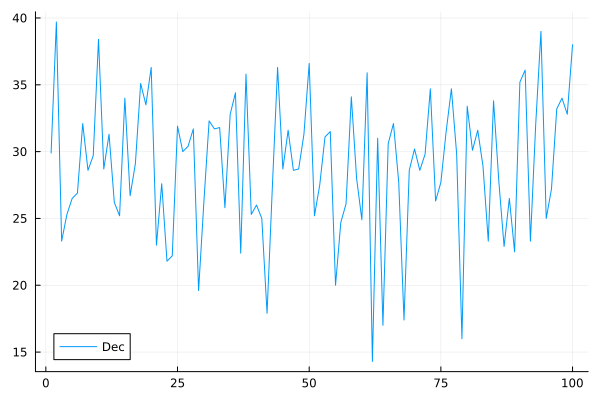

In [12]:
plot(1:100, dectemp, label="Dec", legend=:bottomleft)

In [13]:
savefig("tempChicago100dec.png")

"C:\\Users\\jan\\Courses\\MCS472\\Spring26\\Lec05\\tempChicago100dec.png"

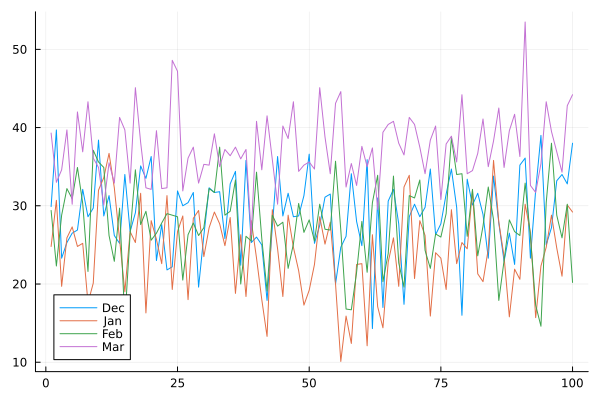

In [14]:
plot!(1:100, jantemp, label="Jan")
plot!(1:100, febtemp, label="Feb")
plot!(1:100, martemp, label="Mar")

In [15]:
savefig("tempChicago100years.png")

"C:\\Users\\jan\\Courses\\MCS472\\Spring26\\Lec05\\tempChicago100years.png"